<a href="https://colab.research.google.com/github/fcoliveira-utfpr/aquacrop_ml/blob/main/estimativas_aqua_crop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Bibliotecas

# **INÍCIO - IMPORTANDRO BIBLIOTECAS**

---

In [17]:
!pip install aquacrop   -q
!pip install scipy   -q
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from aquacrop import AquaCropModel, Soil, Crop, InitialWaterContent, IrrigationManagement
from aquacrop.utils import prepare_weather, get_filepath, prepare_lars_weather,select_lars_wdf
from datetime import datetime

import json
import requests
import os
import openpyxl
from google.colab import files
import itertools
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor



# **Carregando Municípios**

---

In [18]:
url = "https://raw.githubusercontent.com/fcoliveira-utfpr/aquacrop_ml/refs/heads/main/produtividade_locais.csv"
df = pd.read_csv(url)

# Correção para o SyntaxError: remover o '.' final
cidade = df['Municipios']

df.drop(columns=['Municipios'], inplace=True)

# Identifica colunas que podem conter valores numéricos com vírgula como separador decimal
numeric_cols_potential = ['Latitude', 'Longitude', 'Altitude'] + [col for col in df.columns if str(col).isdigit()]

for col in numeric_cols_potential:
    if col in df.columns:
        # Substitui vírgulas por pontos e converte para numérico
        df[col] = df[col].astype(str).str.replace(',', '.', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce') # 'coerce' transforma erros em NaN
df["Municipios"] = cidade
df_municipios = df

# **Baixando dados do NASA-POWER e calculando ETo DIÁRIOS**

---

In [19]:
# Método  Referência
# Penman-Monteith ## PM-FAO56 ##
def PM_FAO56(s, Rn, gama, u2, es, ea, Tmed):
    """
    s: declividade da curva de pressão de vapor de saturação (kPa/°C)
    Rn: radiação líquida à superfície (MJ/m²/dia)
    gama: constante psicrométrica (kPa/°C)
    u2: velocidade do vento a 2 m de altura (m/s)
    es: pressão de vapor de saturação (kPa)
    ea: pressão de vapor atual (kPa)
    Tmed: temperatura média do ar (°C)
    """
    ETo1 = 0.408 * s * Rn
    ETo2 = (gama * 900 * u2 * (es - ea)) / (Tmed + 273)
    ETo3 = s + gama * (1 + 0.34 * u2)
    return (ETo1 + ETo2) / ETo3  # mm/dia

In [20]:
cidades = df_municipios['Municipios'].tolist()
cidades

# Período de análise
ano_inicial = 2015
ano_final = 2025

# Datas de início e fim do período
data_ini = datetime(ano_inicial, 1, 1).date()
data_fim = datetime(ano_final, 12, 31).date()

ini = int(data_ini.strftime('%Y%m%d'))
fin = int(data_fim.strftime('%Y%m%d'))

# Parâmetros que o professor usou
# T2M_MIN: temperatura mínima
# T2M_MAX: temperatura máxima
# PRECTOTCORR: precipitação corrigida
# RH2M: umidade relativa
# WS2M: vento a 2m
# ALLSKY_SFC_SW_DWN: radiação solar global
# TOA_SW_DWN: radiação extraterrestre
base_url = (
    "https://power.larc.nasa.gov/api/temporal/daily/point"
    "?parameters=T2M_MIN,T2M_MAX,PRECTOTCORR,RH2M,WS2M,ALLSKY_SFC_SW_DWN,TOA_SW_DWN"
    "&community=RE"
    "&longitude={longitude}"
    "&latitude={latitude}"
    "&start={ini}"
    "&end={fin}"
    "&format=JSON"
)

dfs_cidades = []

for cid in cidades:
    municipio_data = df_municipios[df_municipios['Municipios'] == cid].iloc[0]
    nome_cidade = municipio_data["Municipios"]
    latitude = municipio_data["Latitude"]
    longitude = municipio_data["Longitude"]
    alt = municipio_data["Altitude"]

    api_request_url = base_url.format(
        longitude=longitude,
        latitude=latitude,
        ini=ini,
        fin=fin
    )

    response = requests.get(url=api_request_url, verify=True, timeout=120)
    response.raise_for_status()

    dados_json = response.json()
    propriedades = dados_json['properties']

    # A parte importante está em propriedades['parameter']
    parametros = propriedades['parameter']

    datas_str = sorted(list(parametros['T2M_MIN'].keys()))
    datas = [datetime.strptime(d, "%Y%m%d").date() for d in datas_str]

    # Constrói o DataFrame básico com a coluna Data
    df = pd.DataFrame({'Data': datas})

    # Temperatura mínima
    df['Tmin'] = [parametros['T2M_MIN'][d] for d in datas_str]

    # Temperatura máxima
    df['Tmax'] = [parametros['T2M_MAX'][d] for d in datas_str]

    # Chuva (PRECIPITAÇÃO CORRIGIDA)
    df['Chuva'] = [parametros['PRECTOTCORR'][d] for d in datas_str]

    # Umidade relativa
    df['UR'] = [parametros['RH2M'][d] for d in datas_str]

    # Vento médio a 2m
    df['U2'] = [parametros['WS2M'][d] for d in datas_str]

    # Radiação solar global (Rs) e extraterrestre (Qo), em kWh/m²d (converteremos depois)
    df['Rs_raw'] = [parametros['ALLSKY_SFC_SW_DWN'][d] for d in datas_str]
    df['Qo_raw'] = [parametros['TOA_SW_DWN'][d] for d in datas_str]

    # Converter Rs e Qo para MJ/m²/dia (kWh * 3.6)
    df['Rs'] = df['Rs_raw'] * 3.6
    df['Qo'] = df['Qo_raw'] * 3.6

    # Temperatura média
    df['Tmed'] = (df['Tmax'] + df['Tmin']) / 2

    # Pressão atmosférica (Patm) – depende da altitude
    df['Patm'] = 101.3 * ((293 - 0.0065 * alt) / 293) ** 5.26

    # Número do dia do ano (NDA)
    df['NDA'] = [pd.to_datetime(d).timetuple().tm_yday for d in df['Data']]

    # Declinação solar
    def dec_sol(NDA):
        return 23.45 * np.sin(np.deg2rad(360/365 * (NDA - 80)))

    df['d'] = df['NDA'].apply(dec_sol)

    # Hora do nascer do sol (Hn), em graus (igual ao professor)
    def hora_na_sol(d, Lat):
        return np.rad2deg(np.arccos(-(np.tan(np.deg2rad(Lat)) * np.tan(np.deg2rad(d)))))

    df['Hn'] = df['d'].apply(lambda d_: hora_na_sol(d_, latitude))

    # Relação (d/D)^2 (correção da distância Terra-Sol)
    def relacao_d_D_2(NDA):
        return 1 + 0.033 * np.cos(np.deg2rad(NDA * 360/365))

    df['(d/D)²'] = df['NDA'].apply(relacao_d_D_2)

    # BOC (balanço de onda curta: Rs * (1 - 25%))
    df['BOC'] = df['Rs'] * (1 - 25/100)

    # Função de pressão de saturação e
    def e_saturacao(temp):
        return 0.6108 * 10 ** ((7.5 * temp) / (237.3 + temp))

    # es_Tmax, es_Tmin, es médio
    df['es_Tmax'] = df['Tmax'].apply(e_saturacao)
    df['es_Tmin'] = df['Tmin'].apply(e_saturacao)
    df['es'] = (df['es_Tmax'] + df['es_Tmin']) / 2

    # ea – pressão parcial de vapor
    df['ea'] = (df['UR'] / 100.0) * df['es']

    # QGcs (radição em céu claro)
    df['QGcs'] = df['Qo'] * (0.75 + (2e-5) * alt)

    # BOL (balanço de onda longa)
    def BOL(tmax, tmin, eaa, qg, qgcs):
        a = 4.903e-9 * (((tmax + 273.16)**4 + (tmin + 273.16)**4) / 2)
        b = (0.34 - 0.14 * (eaa)**0.5)
        c = 1.35 * (qg / qgcs) - 0.35
        return -(a * b * c)

    df['BOL'] = df.apply(lambda x: BOL(x['Tmax'], x['Tmin'], x['ea'], x['Rs'], x['QGcs']), axis=1)

    # Rn – saldo de radiação
    df['Rn'] = df['BOC'] + df['BOL']

    # s – declividade da curva de saturação
    df['s'] = (4098 * df['es']) / (df['Tmed'] + 237.3) ** 2

    # gama – constante psicrométrica
    df['gama'] = (0.665e-3) * df['Patm']

    # Metadados da cidade
    df['Municipio'] = nome_cidade
    df['Lat'] = latitude
    df['Lon'] = longitude
    df['Alt'] = alt

    ###### calculando ETo
    df['EToPM_FAO56'] = df.apply(lambda x: PM_FAO56(x['s'], x['Rn'], x['gama'], x['U2'], x['es'], x['ea'], x['Tmed']), axis=1)

    dfs_cidades.append(df)

# Junta tudo num único DataFrame
df_clima = pd.concat(dfs_cidades, ignore_index=True)

#para baixar para excel os dados tire o # da última linha
base_dados = 'NP'
from google.colab import files
#df_clima.to_excel(f'_{base_dados}.xlsx')
#files.download(f'_{base_dados}.xlsx')

df_clima

,Data,Tmin,Tmax,Chuva,UR,U2,Rs_raw,Qo_raw,Rs,Qo,...,QGcs,BOL,Rn,s,gama,Municipio,Lat,Lon,Alt,EToPM_FAO56
0,2015-01-01,21.08,26.31,5.88,90.79,0.05,6.1462,11.9638,22.12632,43.06968,...,32.915572,-2.345483,14.249257,0.178147,0.061953,Cascavel,-25.03,-53.38,712,4.305382
1,2015-01-02,21.57,28.33,4.06,83.90,0.05,3.6245,11.9561,13.04820,43.04196,...,32.894388,-0.791485,8.994665,0.191514,0.061953,Cascavel,-25.03,-53.38,712,2.780390
2,2015-01-03,20.63,26.96,0.81,85.50,0.10,4.2600,11.9491,15.33600,43.01676,...,32.875129,-1.238269,10.263731,0.179971,0.061953,Cascavel,-25.03,-53.38,712,3.121757
3,2015-01-04,21.21,27.52,7.91,87.15,0.06,6.6775,11.9434,24.03900,42.99624,...,32.859446,-2.696246,15.333004,0.185377,0.061953,Cascavel,-25.03,-53.38,712,4.683027
4,2015-01-05,20.65,29.05,1.14,83.73,0.13,7.7813,11.9383,28.01268,42.97788,...,32.845415,-3.410680,17.598830,0.192337,0.061953,Cascavel,-25.03,-53.38,712,5.422806
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40175,2025-12-27,22.03,31.76,0.28,77.26,0.80,8.4036,11.9390,30.25296,42.98040,...,32.685735,-3.733675,18.956045,0.215441,0.063346,Toledo,-24.70,-53.78,524,6.057548
40176,2025-12-28,22.97,31.72,0.48,79.93,0.72,5.0234,11.9388,18.08424,42.97968,...,32.685187,-1.555358,12.007822,0.218949,0.063346,Toledo,-24.70,-53.78,524,3.946625
40177,2025-12-29,22.44,30.09,5.71,82.65,0.66,7.4546,11.9369,26.83656,42.97284,...,32.679985,-3.059185,17.068235,0.205891,0.063346,Toledo,-24.70,-53.78,524,5.326927
40178,2025-12-30,22.42,28.75,8.51,85.46,0.58,6.7154,11.9311,24.17544,42.95196,...,32.664107,-2.633959,15.497621,0.197467,0.063346,Toledo,-24.70,-53.78,524,4.764679


In [21]:
# Primeiro, converter a coluna Data para datetime
df_clima['Data'] = pd.to_datetime(df_clima['Data'])

# Extrair o ano
df_clima['Ano'] = df_clima['Data'].dt.year

# Passo 1: Calcular totais/médias POR ANO para cada município
df_por_ano = df_clima.groupby(['Municipio', 'Ano']).agg({
    'Chuva': 'sum',
    'Tmin': 'mean',
    'Tmax': 'mean',
    'UR': 'mean',
     'U2': 'mean',
     'Rs': 'mean',
     'Rn': 'mean',
     'EToPM_FAO56': 'sum'
}).reset_index()

# Passo 2: Calcular a média ENTRE os anos para cada município
df_media_anual = df_por_ano.groupby('Municipio').agg({
    'Chuva': 'mean',
    'Tmin': 'mean',
    'Tmax': 'mean',
    'UR': 'mean',
     'U2': 'mean',
     'Rs': 'mean',
     'Rn': 'mean',
     'EToPM_FAO56': 'mean'
}).reset_index()

# Renomear as colunas para ficar mais claro
df_media_anual.columns = [
    'Municipio',
    'Chuva_Media_Anual_mm',
    'Tmin_Media_Anual',
    'Tmax_Media_Anual',
    'UR_Media_Anual',
    'U2_Media_Anual',
    'Rs_Media_Anual',
    'Rn_Media_Anual',
    'EToPM_FAO56_Media_Anual'
]

# Visualizar o resultado
df_media_anual

,Municipio,Chuva_Media_Anual_mm,Tmin_Media_Anual,Tmax_Media_Anual,UR_Media_Anual,U2_Media_Anual,Rs_Media_Anual,Rn_Media_Anual,EToPM_FAO56_Media_Anual
0,Cascavel,1591.727273,15.739244,26.188335,78.268489,0.092409,17.446550,9.989346,1094.598009
1,Foz do Iguaçu,1547.378182,18.463119,28.042974,73.878193,0.867982,17.605666,10.094007,1231.194038
2,Guaíra,1518.942727,18.309577,29.378395,74.217070,0.612724,17.637940,10.261613,1228.562866
3,Marechal Cândido Rondon,1570.490000,19.518418,28.119765,72.374999,1.573005,17.637940,10.141491,1337.583601
4,Matelândia,1614.521818,16.763262,27.580069,75.782584,0.186175,17.446550,9.980317,1115.050157
5,Medianeira,1547.378182,18.463119,28.042974,73.878193,0.867982,17.605666,10.110153,1235.561333
6,Santa Helena,1580.769091,19.946647,27.679440,71.361584,2.321403,17.637940,10.085429,1423.798987
7,São Miguel do Iguaçu,1547.378182,18.463119,28.042974,73.878193,0.867982,17.605666,10.097091,1232.026114
8,São Pedro do Iguaçu,1578.379091,15.944649,27.397651,76.659194,0.746330,17.733097,10.183737,1187.235363
9,Toledo,1550.694545,16.898491,28.125144,75.091210,0.991413,17.733097,10.200395,1239.291251


In [22]:
df_muni = df_municipios

# Lista com os nomes das colunas de anos
anos = ['2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']

# Criar a coluna com a média dos valores
df_muni['yield_med'] = df_muni[anos].mean(axis=1)

# Se quiser ignorar valores NaN no cálculo da média
df_muni['yield_med'] = df_muni[anos].mean(axis=1, skipna=True)
df_muni = df_muni.rename(columns={"Municipios":"Municipio"})
df_climatologia = df_media_anual.merge(
    df_muni,
    on=["Municipio"],
    how="left")
df_climatologia

,Municipio,Chuva_Media_Anual_mm,Tmin_Media_Anual,Tmax_Media_Anual,UR_Media_Anual,U2_Media_Anual,Rs_Media_Anual,Rn_Media_Anual,EToPM_FAO56_Media_Anual,Latitude,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,yield_med
0,Cascavel,1591.727273,15.739244,26.188335,78.268489,0.092409,17.446550,9.989346,1094.598009,-25.03,...,7.234,6.355,5.823,6.570,6.551,4.823,4.486,4.858,4.840,5.8217
1,Foz do Iguaçu,1547.378182,18.463119,28.042974,73.878193,0.867982,17.605666,10.094007,1231.194038,-25.47,...,6.732,4.872,4.747,5.913,6.300,3.600,6.500,6.900,5.950,5.9014
2,Guaíra,1518.942727,18.309577,29.378395,74.217070,0.612724,17.637940,10.261613,1228.562866,-24.19,...,6.511,6.011,5.500,6.700,4.501,3.001,3.998,6.700,3.350,5.2156
3,Marechal Cândido Rondon,1570.490000,19.518418,28.119765,72.374999,1.573005,17.637940,10.141491,1337.583601,-24.57,...,4.947,6.579,5.577,7.208,4.671,3.197,5.645,6.607,4.439,5.5488
4,Matelândia,1614.521818,16.763262,27.580069,75.782584,0.186175,17.446550,9.980317,1115.050157,-25.35,...,6.038,5.247,6.036,6.002,4.879,3.166,5.937,5.715,5.546,5.5775
5,Medianeira,1547.378182,18.463119,28.042974,73.878193,0.867982,17.605666,10.110153,1235.561333,-25.26,...,5.000,5.000,5.500,5.901,5.000,3.500,6.000,6.000,5.456,5.4377
6,Santa Helena,1580.769091,19.946647,27.679440,71.361584,2.321403,17.637940,10.085429,1423.798987,-24.89,...,4.627,5.342,4.528,5.810,2.276,3.016,5.982,6.448,6.011,5.0189
7,São Miguel do Iguaçu,1547.378182,18.463119,28.042974,73.878193,0.867982,17.605666,10.097091,1232.026114,-25.39,...,6.809,5.224,5.211,6.158,5.971,3.505,6.991,6.600,5.958,5.9124
8,São Pedro do Iguaçu,1578.379091,15.944649,27.397651,76.659194,0.746330,17.733097,10.183737,1187.235363,-24.91,...,5.284,4.980,5.310,7.009,4.763,2.806,5.677,6.362,6.500,5.4645
9,Toledo,1550.694545,16.898491,28.125144,75.091210,0.991413,17.733097,10.200395,1239.291251,-24.70,...,6.266,5.448,5.535,7.706,5.041,2.438,6.049,8.009,6.211,5.9812


In [23]:
df_climatologia = df_climatologia[['Chuva_Media_Anual_mm', 'Tmin_Media_Anual',
       'Tmax_Media_Anual', 'UR_Media_Anual', 'U2_Media_Anual',
       'Rs_Media_Anual', 'Rn_Media_Anual', 'EToPM_FAO56_Media_Anual',
       'Latitude', 'Longitude', 'Altitude', 'yield_med']]
df_climatologia

,Chuva_Media_Anual_mm,Tmin_Media_Anual,Tmax_Media_Anual,UR_Media_Anual,U2_Media_Anual,Rs_Media_Anual,Rn_Media_Anual,EToPM_FAO56_Media_Anual,Latitude,Longitude,Altitude,yield_med
0,1591.727273,15.739244,26.188335,78.268489,0.092409,17.446550,9.989346,1094.598009,-25.03,-53.38,712,5.8217
1,1547.378182,18.463119,28.042974,73.878193,0.867982,17.605666,10.094007,1231.194038,-25.47,-54.48,275,5.9014
2,1518.942727,18.309577,29.378395,74.217070,0.612724,17.637940,10.261613,1228.562866,-24.19,-54.23,275,5.2156
3,1570.490000,19.518418,28.119765,72.374999,1.573005,17.637940,10.141491,1337.583601,-24.57,-54.14,327,5.5488
4,1614.521818,16.763262,27.580069,75.782584,0.186175,17.446550,9.980317,1115.050157,-25.35,-53.91,324,5.5775
5,1547.378182,18.463119,28.042974,73.878193,0.867982,17.605666,10.110153,1235.561333,-25.26,-54.09,401,5.4377
6,1580.769091,19.946647,27.679440,71.361584,2.321403,17.637940,10.085429,1423.798987,-24.89,-54.31,238,5.0189
7,1547.378182,18.463119,28.042974,73.878193,0.867982,17.605666,10.097091,1232.026114,-25.39,-54.26,299,5.9124
8,1578.379091,15.944649,27.397651,76.659194,0.746330,17.733097,10.183737,1187.235363,-24.91,-53.89,517,5.4645
9,1550.694545,16.898491,28.125144,75.091210,0.991413,17.733097,10.200395,1239.291251,-24.70,-53.78,524,5.9812


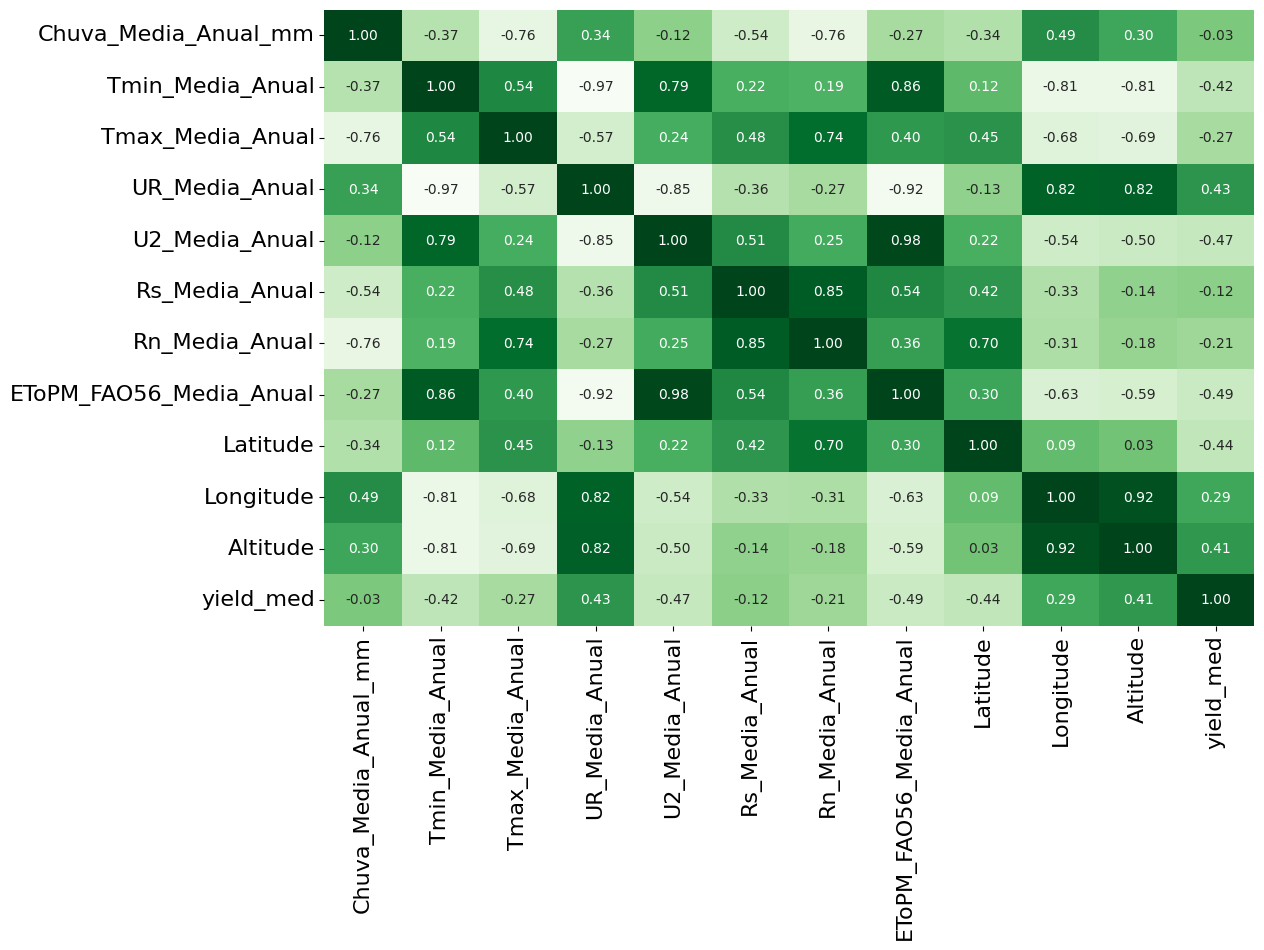

In [24]:
import seaborn as sns
# Gerar a matriz de correlação
correlation_matrix = df_climatologia.corr()

# Criar a figura
plt.figure(figsize=(12, 8))

# Criar o heatmap com os números formatados com ponto
heatmap = sns.heatmap(correlation_matrix, annot=True, cmap='Greens', cbar=False, fmt='.2f')

plt.tick_params(axis='x', which='major', labelsize=16)
plt.tick_params(axis='y', which='major', labelsize=16)


In [25]:
# Calcular o valor absoluto das correlações com yield_med e ordenar
corr_yield_abs = correlation_matrix['yield_med'].abs().sort_values(ascending=False)
corr_yield_abs



,yield_med
yield_med,1.000000
EToPM_FAO56_Media_Anual,0.492232
U2_Media_Anual,0.469808
Latitude,0.436003
UR_Media_Anual,0.433774
Tmin_Media_Anual,0.423611
Altitude,0.410934
Longitude,0.289144
Tmax_Media_Anual,0.268040
Rn_Media_Anual,0.211065


# **Montando dados AQUACROP**

---

In [26]:
# ============================================================
# CLIMA
# ============================================================

df_acrop = df_clima[['Tmin', 'Tmax', 'Chuva','EToPM_FAO56', 'Data', 'Municipio']]

df_acrop.rename(columns={'Tmin': 'MinTemp',
                         'Tmax': 'MaxTemp',
                         'Chuva': 'Precipitation',
                         'EToPM_FAO56': 'ReferenceET',
                         'Data': 'Date',
                        }, inplace=True)

weather_df = df_acrop.copy()

# ============================================================
# SOLO E MANEJO
# ============================================================

soil = Soil('SandyLoam')

init_wc = InitialWaterContent(value=['FC'])

irr_mngt = IrrigationManagement(irrigation_method=0)

# ============================================================
# DATAS DE SEMEADURA (2ª SAFRA)
# ============================================================

planting_dates = [
    #'01/05', #Mês/dia
    #'01/15',
    '01/25',
    #'02/05',
    #'02/15',
    #'02/25',
    #'03/05',
    #'03/15',
    #'03/25',
    #'12/25',
]

/tmp/ipykernel_999/4253395188.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_acrop.rename(columns={'Tmin': 'MinTemp',


# **Rodando simulação AQUACROP**

---

In [ ]:
WP_vals = [30, 32, 34, 36]
HI0_vals = [0.45, 0.48, 0.50]
CCx_vals = [0.90, 0.95]
CGC_vals = [0.012, 0.013]
CDC_vals = [0.006, 0.007]

param_grid = list(itertools.product(
    WP_vals,
    HI0_vals,
    CCx_vals,
    CGC_vals,
    CDC_vals
))

df_params = pd.DataFrame(param_grid, columns=[
    "WP","HI0","CCx","CGC","CDC"
])

df_params

,WP,HI0,CCx,CGC,CDC
0,30,0.45,0.90,0.012,0.006
1,30,0.45,0.90,0.012,0.007
2,30,0.45,0.90,0.013,0.006
3,30,0.45,0.90,0.013,0.007
4,30,0.45,0.95,0.012,0.006
...,...,...,...,...,...
91,36,0.50,0.90,0.013,0.007
92,36,0.50,0.95,0.012,0.006
93,36,0.50,0.95,0.012,0.007
94,36,0.50,0.95,0.013,0.006


In [ ]:
dfs_cidades = []

for _, param in df_params.iterrows():

    WP = param.WP
    HI0 = param.HI0
    CCx = param.CCx
    CGC = param.CGC
    CDC = param.CDC

    for cid in cidades:

        municipio_data = df_municipios[df_municipios['Municipios'] == cid].iloc[0]
        nome_cidade = municipio_data["Municipios"]

        df_loop = weather_df[weather_df['Municipio'] == nome_cidade].drop(columns=['Municipio']).copy()

        df_loop['Date'] = pd.to_datetime(df_loop['Date'])

        start_year = df_loop['Date'].iloc[0].year
        end_year = df_loop['Date'].iloc[-1].year - 1

        results = []

        for year in range(start_year, end_year + 1):

            sim_start = f"{year}/01/01"
            sim_end = f"{year}/12/31"

            for pdate in planting_dates:

                crop = Crop(
                    'Maize',
                    planting_date=pdate,
                    WP=WP,
                    HI0=HI0,
                    CCx=CCx,
                    CGC=CGC,
                    CDC=CDC
                )

                model = AquaCropModel(
                    sim_start_time=sim_start,
                    sim_end_time=sim_end,
                    weather_df=df_loop,
                    soil=soil,
                    crop=crop,
                    initial_water_content=init_wc,
                    irrigation_management=irr_mngt
                )

                model.run_model(till_termination=True)

                final = model._outputs.final_stats

                yield_fresh = final["Fresh yield (tonne/ha)"].values[0]

                results.append({
                    "Year": year,
                    "PlantingDate": pdate,
                    "YieldFresh_ton_ha": yield_fresh,
                    "Municipio": nome_cidade,
                    "WP": WP,
                    "HI0": HI0,
                    "CCx": CCx,
                    "CGC": CGC,
                    "CDC": CDC
                })

        dfs_cidades.append(pd.DataFrame(results))

df_simulated = pd.concat(dfs_cidades, ignore_index=True)
df_simulated

,Year,PlantingDate,YieldFresh_ton_ha,Municipio,WP,HI0,CCx,CGC,CDC
0,2015,01/25,13.081934,Cascavel,30.0,0.45,0.90,0.012,0.006
1,2016,01/25,11.837301,Cascavel,30.0,0.45,0.90,0.012,0.006
2,2017,01/25,12.797159,Cascavel,30.0,0.45,0.90,0.012,0.006
3,2018,01/25,12.808536,Cascavel,30.0,0.45,0.90,0.012,0.006
4,2019,01/25,13.170263,Cascavel,30.0,0.45,0.90,0.012,0.006
...,...,...,...,...,...,...,...,...,...
9595,2020,01/25,17.352137,Toledo,36.0,0.50,0.95,0.013,0.007
9596,2021,01/25,17.692852,Toledo,36.0,0.50,0.95,0.013,0.007
9597,2022,01/25,16.346810,Toledo,36.0,0.50,0.95,0.013,0.007
9598,2023,01/25,17.552887,Toledo,36.0,0.50,0.95,0.013,0.007


In [ ]:
df_simulated.to_csv('df_simulated4.csv')
files.download('df_simulated4.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Carregando dados de produtividade real e simulated
---

In [27]:
url = "https://raw.githubusercontent.com/fcoliveira-utfpr/aquacrop_ml/refs/heads/main/produtividade_locais.csv"
df = pd.read_csv(url)

# Correção para o SyntaxError: remover o '.' final
cidade = df['Municipios']

df.drop(columns=['Municipios'], inplace=True)

# Identifica colunas que podem conter valores numéricos com vírgula como separador decimal
numeric_cols_potential = ['Latitude', 'Longitude', 'Altitude'] + [col for col in df.columns if str(col).isdigit()]

for col in numeric_cols_potential:
    if col in df.columns:
        # Substitui vírgulas por pontos e converte para numérico
        df[col] = df[col].astype(str).str.replace(',', '.', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce') # 'coerce' transforma erros em NaN
df["Municipios"] = cidade
df_municipios = df

url10 = "https://raw.githubusercontent.com/fcoliveira-utfpr/aquacrop_ml/refs/heads/main/df_climatologia.csv"
df10 = pd.read_csv(url10)
df10.drop(columns=['Unnamed: 0'], inplace=True)
df10

# Primeiro, converter a coluna Data para datetime
df10['Data'] = pd.to_datetime(df10['Data'])

# Extrair o ano
df10['Ano'] = df10['Data'].dt.year

# Passo 1: Calcular totais/médias POR ANO para cada município
df_por_ano = df10.groupby(['Municipio', 'Ano']).agg({
    'Chuva': 'sum',
    'Tmin': 'mean',
    'Tmax': 'mean',
    'UR': 'mean',
     'U2': 'mean',
     'Rs': 'mean',
     'Rn': 'mean',
     'EToPM_FAO56': 'sum'
}).reset_index()

# Passo 2: Calcular a média ENTRE os anos para cada município
df_media_anual = df_por_ano.groupby('Municipio').agg({
    'Chuva': 'mean',
    'Tmin': 'mean',
    'Tmax': 'mean',
    'UR': 'mean',
     'U2': 'mean',
     'Rs': 'mean',
     'Rn': 'mean',
     'EToPM_FAO56': 'mean'
}).reset_index()

# Renomear as colunas para ficar mais claro
df_media_anual.columns = [
    'Municipio',
    'Chuva_Media_Anual_mm',
    'Tmin_Media_Anual',
    'Tmax_Media_Anual',
    'UR_Media_Anual',
    'U2_Media_Anual',
    'Rs_Media_Anual',
    'Rn_Media_Anual',
    'EToPM_FAO56_Media_Anual'
]

df_muni = df_municipios

# Lista com os nomes das colunas de anos
anos = ['2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']

# Criar a coluna com a média dos valores
df_muni['yield_med'] = df_muni[anos].mean(axis=1)

# Se quiser ignorar valores NaN no cálculo da média
df_muni['yield_med'] = df_muni[anos].mean(axis=1, skipna=True)
df_muni = df_muni.rename(columns={"Municipios":"Municipio"})
df_climatologia = df_media_anual.merge(
    df_muni,
    on=["Municipio"],
    how="left")
df_climatologia

,Municipio,Chuva_Media_Anual_mm,Tmin_Media_Anual,Tmax_Media_Anual,UR_Media_Anual,U2_Media_Anual,Rs_Media_Anual,Rn_Media_Anual,EToPM_FAO56_Media_Anual,Latitude,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,yield_med
0,Cascavel,1591.727273,15.739244,26.188335,78.268489,0.092409,17.446550,9.989346,1094.598009,-25.03,...,7.234,6.355,5.823,6.570,6.551,4.823,4.486,4.858,4.840,5.8217
1,Foz do Iguaçu,1547.378182,18.463119,28.042974,73.878193,0.867982,17.605666,10.094007,1231.194038,-25.47,...,6.732,4.872,4.747,5.913,6.300,3.600,6.500,6.900,5.950,5.9014
2,Guaíra,1518.942727,18.309577,29.378395,74.217070,0.612724,17.637940,10.261613,1228.562866,-24.19,...,6.511,6.011,5.500,6.700,4.501,3.001,3.998,6.700,3.350,5.2156
3,Marechal Cândido Rondon,1570.490000,19.518418,28.119765,72.374999,1.573005,17.637940,10.141491,1337.583601,-24.57,...,4.947,6.579,5.577,7.208,4.671,3.197,5.645,6.607,4.439,5.5488
4,Matelândia,1614.521818,16.763262,27.580069,75.782584,0.186175,17.446550,9.980317,1115.050157,-25.35,...,6.038,5.247,6.036,6.002,4.879,3.166,5.937,5.715,5.546,5.5775
5,Medianeira,1547.378182,18.463119,28.042974,73.878193,0.867982,17.605666,10.110153,1235.561333,-25.26,...,5.000,5.000,5.500,5.901,5.000,3.500,6.000,6.000,5.456,5.4377
6,Santa Helena,1580.769091,19.946647,27.679440,71.361584,2.321403,17.637940,10.085429,1423.798987,-24.89,...,4.627,5.342,4.528,5.810,2.276,3.016,5.982,6.448,6.011,5.0189
7,São Miguel do Iguaçu,1547.378182,18.463119,28.042974,73.878193,0.867982,17.605666,10.097091,1232.026114,-25.39,...,6.809,5.224,5.211,6.158,5.971,3.505,6.991,6.600,5.958,5.9124
8,São Pedro do Iguaçu,1578.379091,15.944649,27.397651,76.659194,0.746330,17.733097,10.183737,1187.235363,-24.91,...,5.284,4.980,5.310,7.009,4.763,2.806,5.677,6.362,6.500,5.4645
9,Toledo,1550.694545,16.898491,28.125144,75.091210,0.991413,17.733097,10.200395,1239.291251,-24.70,...,6.266,5.448,5.535,7.706,5.041,2.438,6.049,8.009,6.211,5.9812


In [28]:

cidades = df_climatologia['Municipio'].tolist()

url2 = "https://raw.githubusercontent.com/fcoliveira-utfpr/aquacrop_ml/refs/heads/main/df_simulated1.csv"
url3 = "https://raw.githubusercontent.com/fcoliveira-utfpr/aquacrop_ml/refs/heads/main/df_simulated2.csv"
url4 = "https://raw.githubusercontent.com/fcoliveira-utfpr/aquacrop_ml/refs/heads/main/df_simulated3.csv"
url5 = "https://raw.githubusercontent.com/fcoliveira-utfpr/aquacrop_ml/refs/heads/main/df_simulated4.csv"

df2 = pd.read_csv(url2)
df3 = pd.read_csv(url3)
df4 = pd.read_csv(url4)
df5 = pd.read_csv(url5)

df2.drop(columns=['Unnamed: 0'], inplace=True)
df3.drop(columns=['Unnamed: 0'], inplace=True)
df4.drop(columns=['Unnamed: 0'], inplace=True)
df5.drop(columns=['Unnamed: 0'], inplace=True)

df_simulated = pd.concat([df2, df3, df4, df5], ignore_index=True)

In [29]:
# Melting apenas para os anos (dados anuais)
df_anual = df_climatologia.melt(
    id_vars=['Municipio', 'Chuva_Media_Anual_mm', 'Tmin_Media_Anual',
             'Tmax_Media_Anual', 'UR_Media_Anual', 'U2_Media_Anual',
             'Rs_Media_Anual', 'Rn_Media_Anual', 'EToPM_FAO56_Media_Anual',
             'Latitude', 'Longitude', 'Altitude'],
    value_vars=['2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024'],
    var_name="Ano",
    value_name="Yield_obs"
)

df_anual


,Municipio,Chuva_Media_Anual_mm,Tmin_Media_Anual,Tmax_Media_Anual,UR_Media_Anual,U2_Media_Anual,Rs_Media_Anual,Rn_Media_Anual,EToPM_FAO56_Media_Anual,Latitude,Longitude,Altitude,Ano,Yield_obs
0,Cascavel,1591.727273,15.739244,26.188335,78.268489,0.092409,17.446550,9.989346,1094.598009,-25.03,-53.38,712,2015,6.677
1,Foz do Iguaçu,1547.378182,18.463119,28.042974,73.878193,0.867982,17.605666,10.094007,1231.194038,-25.47,-54.48,275,2015,7.500
2,Guaíra,1518.942727,18.309577,29.378395,74.217070,0.612724,17.637940,10.261613,1228.562866,-24.19,-54.23,275,2015,5.884
3,Marechal Cândido Rondon,1570.490000,19.518418,28.119765,72.374999,1.573005,17.637940,10.141491,1337.583601,-24.57,-54.14,327,2015,6.618
4,Matelândia,1614.521818,16.763262,27.580069,75.782584,0.186175,17.446550,9.980317,1115.050157,-25.35,-53.91,324,2015,7.209
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Medianeira,1547.378182,18.463119,28.042974,73.878193,0.867982,17.605666,10.110153,1235.561333,-25.26,-54.09,401,2024,5.456
96,Santa Helena,1580.769091,19.946647,27.679440,71.361584,2.321403,17.637940,10.085429,1423.798987,-24.89,-54.31,238,2024,6.011
97,São Miguel do Iguaçu,1547.378182,18.463119,28.042974,73.878193,0.867982,17.605666,10.097091,1232.026114,-25.39,-54.26,299,2024,5.958
98,São Pedro do Iguaçu,1578.379091,15.944649,27.397651,76.659194,0.746330,17.733097,10.183737,1187.235363,-24.91,-53.89,517,2024,6.500


In [30]:
df_calibration = df_simulated.merge(
    df_anual,
    on=["Municipio"],
    how="left"
)
df_calibration["Error"] = (
    df_calibration["Yield_obs"] -
    df_calibration["YieldFresh_ton_ha"] #YieldFresh_ton_ha
)
df_calibration["Plant_DOY"] = pd.to_datetime(
    df_calibration["PlantingDate"],
    format="%m/%d"
).dt.dayofyear
df_calibration

,Year,PlantingDate,YieldFresh_ton_ha,Municipio,WP,HI0,CCx,CGC,CDC,Chuva_Media_Anual_mm,...,Rs_Media_Anual,Rn_Media_Anual,EToPM_FAO56_Media_Anual,Latitude,Longitude,Altitude,Ano,Yield_obs,Error,Plant_DOY
0,2015,02/15,12.576875,Cascavel,30.0,0.45,0.90,0.012,0.006,1591.727273,...,17.446550,9.989346,1094.598009,-25.03,-53.38,712,2015,6.677,-5.899875,46
1,2015,02/15,12.576875,Cascavel,30.0,0.45,0.90,0.012,0.006,1591.727273,...,17.446550,9.989346,1094.598009,-25.03,-53.38,712,2016,7.234,-5.342875,46
2,2015,02/15,12.576875,Cascavel,30.0,0.45,0.90,0.012,0.006,1591.727273,...,17.446550,9.989346,1094.598009,-25.03,-53.38,712,2017,6.355,-6.221875,46
3,2015,02/15,12.576875,Cascavel,30.0,0.45,0.90,0.012,0.006,1591.727273,...,17.446550,9.989346,1094.598009,-25.03,-53.38,712,2018,5.823,-6.753875,46
4,2015,02/15,12.576875,Cascavel,30.0,0.45,0.90,0.012,0.006,1591.727273,...,17.446550,9.989346,1094.598009,-25.03,-53.38,712,2019,6.570,-6.006875,46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
383995,2024,01/25,17.586014,Toledo,36.0,0.50,0.95,0.013,0.007,1550.694545,...,17.733097,10.200395,1239.291251,-24.70,-53.78,524,2020,5.041,-12.545014,25
383996,2024,01/25,17.586014,Toledo,36.0,0.50,0.95,0.013,0.007,1550.694545,...,17.733097,10.200395,1239.291251,-24.70,-53.78,524,2021,2.438,-15.148014,25
383997,2024,01/25,17.586014,Toledo,36.0,0.50,0.95,0.013,0.007,1550.694545,...,17.733097,10.200395,1239.291251,-24.70,-53.78,524,2022,6.049,-11.537014,25
383998,2024,01/25,17.586014,Toledo,36.0,0.50,0.95,0.013,0.007,1550.694545,...,17.733097,10.200395,1239.291251,-24.70,-53.78,524,2023,8.009,-9.577014,25


In [31]:
def rmse(x):
    return np.sqrt(mean_squared_error(x["Yield_obs"], x["YieldFresh_ton_ha"]))

def mae(x):
    return mean_absolute_error(x["Yield_obs"], x["YieldFresh_ton_ha"])

df_error = (
    df_calibration
    .groupby(["WP","HI0","CCx","CGC","CDC"])
    .apply(rmse)
    .reset_index(name="RMSE")
)

df_error.sort_values("RMSE")
best_params = df_error.sort_values("RMSE").iloc[0]
best_params

/tmp/ipykernel_999/3161467691.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(rmse)


,0
WP,30.000000
HI0,0.450000
CCx,0.900000
CGC,0.012000
CDC,0.006000
RMSE,7.021941


# ML com variáveis do AquaCrop
---

In [32]:
df_calibration.columns

Index(['Year', 'PlantingDate', 'YieldFresh_ton_ha', 'Municipio', 'WP', 'HI0',
       'CCx', 'CGC', 'CDC', 'Chuva_Media_Anual_mm', 'Tmin_Media_Anual',
       'Tmax_Media_Anual', 'UR_Media_Anual', 'U2_Media_Anual',
       'Rs_Media_Anual', 'Rn_Media_Anual', 'EToPM_FAO56_Media_Anual',
       'Latitude', 'Longitude', 'Altitude', 'Ano', 'Yield_obs', 'Error',
       'Plant_DOY'],
      dtype='object')

In [ ]:
features = [
    "YieldFresh_ton_ha",  # saída do AquaCrop
    "WP",
    "HI0",
    "CCx",
    "CGC",
    "CDC",
    "Latitude",
    "Longitude",
    "Altitude",
    "Plant_DOY",
    'Chuva_Media_Anual_mm', 'Tmin_Media_Anual', 'UR_Media_Anual', 'U2_Media_Anual', 'EToPM_FAO56_Media_Anual'
]

target = "Error"

In [ ]:
# Separando treino e teste
X = df_calibration[features]
y = df_calibration[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=500, random_state=42)

In [ ]:
error_pred = model.predict(X_test)

yield_sim = X_test["YieldFresh_ton_ha"].values

yield_corrected = yield_sim + error_pred

rmse_aquacrop = np.sqrt(
    mean_squared_error(
        df_calibration.loc[X_test.index, "Yield_obs"],
        yield_sim
    )
)

rmse_hybrid = np.sqrt(
    mean_squared_error(
        df_calibration.loc[X_test.index, "Yield_obs"],
        yield_corrected
    )
)
print("RMSE AquaCrop:", rmse_aquacrop)
print("RMSE AquaCrop + ML:", rmse_hybrid)

RMSE AquaCrop: 9.098721084057173
RMSE AquaCrop + ML: 0.39900264684977027


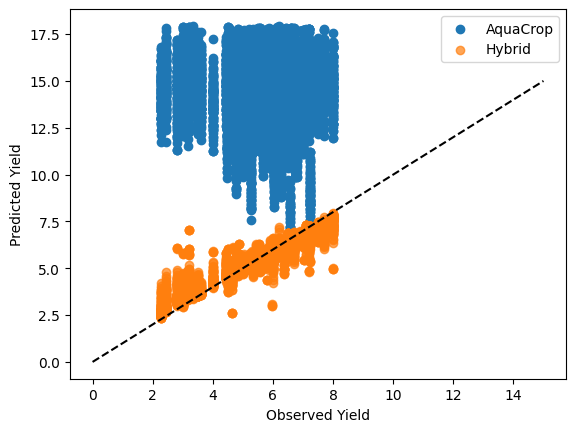

In [ ]:
obs = df_calibration.loc[X_test.index, "Yield_obs"]

plt.scatter(obs, yield_sim, label="AquaCrop")
plt.scatter(obs, yield_corrected, label="Hybrid", alpha=0.7)

plt.plot([0,15],[0,15],'k--')

plt.xlabel("Observed Yield")
plt.ylabel("Predicted Yield")
plt.legend()
plt.show()

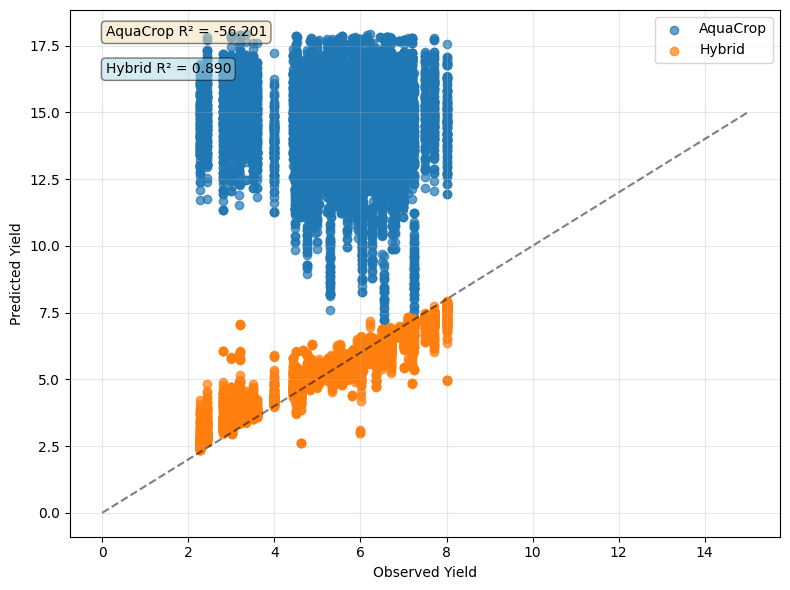

In [ ]:
from sklearn.metrics import r2_score
import numpy as np

obs = df_calibration.loc[X_test.index, "Yield_obs"]

# Calcular R² para ambos os modelos
r2_aquacrop = r2_score(obs, yield_sim)
r2_hybrid = r2_score(obs, yield_corrected)

# Criar o gráfico
plt.figure(figsize=(8, 6))

plt.scatter(obs, yield_sim, label="AquaCrop", alpha=0.7)
plt.scatter(obs, yield_corrected, label="Hybrid", alpha=0.7)

plt.plot([0,15], [0,15], 'k--', alpha=0.5)

# Adicionar texto com os valores de R²
plt.text(0.05, 0.95, f'AquaCrop R² = {r2_aquacrop:.3f}',
         transform=plt.gca().transAxes,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.text(0.05, 0.88, f'Hybrid R² = {r2_hybrid:.3f}',
         transform=plt.gca().transAxes,
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.xlabel("Observed Yield")
plt.ylabel("Predicted Yield")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

importance

,0
YieldFresh_ton_ha,0.858716
WP,0.024720
Altitude,0.021118
HI0,0.020946
Latitude,0.020362
Plant_DOY,0.018298
CCx,0.015975
Longitude,0.015868
CGC,0.002033
CDC,0.001965


# Salvar modelo
---

In [ ]:
import joblib

joblib.dump(best_rf, "rf_aquacrop_error_model.pkl")
#model = joblib.load("rf_aquacrop_error_model.pkl")

#Teste espacial